In [1]:
#Aim: to keep the notebook as clean as possible. 

In [2]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr # to read .rds files

%matplotlib inline

In [3]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
path_rds = "/Users/ud4/Documents/FACEMDS/Models/obs_data"
path_obs_data = "/Users/ud4/Documents/FACEMDS/L2FR_Calc"
path_save_results = "/Users/ud4/Documents/FACEMDS/Figures_Paper"
#path_save_results = "/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/Evaluation_Paper_Dir/Results"

In [4]:
# Load the RDS file
# read mean annual
result = pyreadr.read_r(f'{path_rds}/OBS_ax.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data = result[None]  # None is the key for the single R object in the file

# SE
result = pyreadr.read_r(f'{path_rds}/OBS_ase.rds')
my_data_se = result[None]  # None is the key for the single R object in the file

In [5]:

fnames={}



case_abr = { # case abbreviations
    "SC" : "FACE_1PFT_r250210_Best_Cal",
    "SCnew" : "FACE_1PFT_r250421_reCal",
    "SCnV" : "FACE_1PFT_r250425_MCMCV",
    "SC4n": "FACE_1PFT_r250506_reCalN2", # d2bl fixed at 0.065, recalibration
    "SD" : "FACE_1PFT_r2503121_SD_b4OLMTparms", 
    "EC" : "FACE_1PFT_r250314_NoLog_CalParams",
    "ED" : "FACE_1PFT_r2503121_ED_b4OLMTparms",

}

site_abr = { # case abbreviations
    "ORNL" : "US-ORN",
    "DUKE" : "US-DUK",
}


sites= ("US-ORN", "US-DUK")
run_cases = ["aCO2", "eCO2"]
sim_cases = [
            "COnly",
            "RD",
            "ECA",
            ]

for c_abr in case_abr:
    case_id = case_abr[c_abr]
    for s_abr in site_abr:
        site = site_abr[s_abr]
        for run_case in run_cases:
            # COnly
            fnames[f"{c_abr}_{s_abr}_COnly_{run_case}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}.nc"
            # RD
            #fn = ['RD','ECA']
            for fn in ['RD','ECA']:
                fnames[f"{c_abr}_{s_abr}_{fn}_{run_case}"] = f"{path_in}{case_id}_{fn}_processed/{case_id}_{fn}_{site}_{run_case}.nc"

In [6]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    print (key, ":" , fnames[key])
    ds[key] = xr.open_mfdataset(fnames[key])
    

SC_ORNL_COnly_aCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r250210_Best_Cal_processed/FACE_1PFT_r250210_Best_Cal_US-ORN_aCO2.nc
SC_ORNL_RD_aCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r250210_Best_Cal_RD_processed/FACE_1PFT_r250210_Best_Cal_RD_US-ORN_aCO2.nc
SC_ORNL_ECA_aCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r250210_Best_Cal_ECA_processed/FACE_1PFT_r250210_Best_Cal_ECA_US-ORN_aCO2.nc
SC_ORNL_COnly_eCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r250210_Best_Cal_processed/FACE_1PFT_r250210_Best_Cal_US-ORN_eCO2.nc
SC_ORNL_RD_eCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r250210_Best_Cal_RD_processed/FACE_1PFT_r250210_Best_Cal_RD_US-ORN_eCO2.nc
SC_ORNL_ECA_eCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r250210_Best_Cal_ECA_processed/FACE_1PFT_r250210_Best_Cal_ECA_US-ORN_eCO2.nc
SC_DUKE_COnly_aCO2 : /Users/ud4/FATESMDS

In [7]:

markers_list = [".", "<", "o","^",".", "<", "o","^"]
colors_list = ["red", "green", "blue", "yellow","red", "green", "blue", "yellow"] 

#def tmp_legend_name (key):
#    return key.replace("FACE_1PFT_r250210_Best_Cal_", "")
    
# How long do you want the simulation plots?
max_r_years = 150
if run_case == "spins":
    output_freq = "yearly" # spins
    multiply_factor = 1 # 365 for daily output; else 1 for yearly
else:
    output_freq = "daily" # spins
    multiply_factor = 365
    if "CO2" in run_case:
        max_r_years = 12+5

In [8]:
# dataframe of selected colms 
# relevant columns
rel_cols = ["YEAR", "co2", "site", "NPP", "NUP"]
# if you want to save the filtered dataframe to CSV
#my_data[rel_cols].to_csv("tmp/obs_a.csv")
df_obs_ax = my_data[rel_cols]
df_obs_ase = my_data_se[rel_cols]

NPP_units = "gC m-2 y-1"
NUP_units = "gN m-2 y-1"

# Filter the dataset to keep only rows where site is 'ORNL' or 'DUKE'
df_obs_ax_site = df_obs_ax[df_obs_ax['site'].isin(['ORNL', 'DUKE'])]
df_obs_ase_site = df_obs_ase[df_obs_ase['site'].isin(['ORNL', 'DUKE'])]

filter_co2 = df_obs_ase_site["co2"] == "AMB"
filter_site = df_obs_ase_site["site"] == "ORNL"
df_obs_ase_site[filter_co2][filter_site]

# arrange data into dict!
dict_obs_ax = {}
sites_o= ("ORNL", "DUKE" )
#sites_o= ( "ORNL", )

CO2_cases  = ("AMB", "ELE" )
dict_obs_ax = {}
dict_obs_ase = {} # standard error
dict_obs_aserel = {} #rel standard error = Val SE/Var
for site in sites_o:
    dict_obs_ax    [site] = {}
    dict_obs_ase   [site] = {}
    dict_obs_aserel [site] = {}
    for co2_case in CO2_cases:
        # selected values from mean
        filter_co2 = df_obs_ax_site["co2"] == co2_case
        filter_site = df_obs_ax_site["site"] == site
        dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
        # selected values from standard error
        filter_co2 = df_obs_ase_site["co2"] == co2_case
        filter_site = df_obs_ase_site["site"] == site
        dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
        dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
        dict_obs_aserel[site][co2_case][["NPP", "NUP"]] = df_obs_ase_site[filter_co2][filter_site][["NPP", "NUP"]]/df_obs_ax_site[filter_co2][filter_site][["NPP", "NUP"]]

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_68988/2440484563.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_68988/2440484563.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_68988/2440484563.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_68988/2440484563.py:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_68988/2440484563.py:43: UserWarn

In [9]:
case_abr

{'SC': 'FACE_1PFT_r250210_Best_Cal',
 'SCnew': 'FACE_1PFT_r250421_reCal',
 'SCnV': 'FACE_1PFT_r250425_MCMCV',
 'SC4n': 'FACE_1PFT_r250506_reCalN2',
 'SD': 'FACE_1PFT_r2503121_SD_b4OLMTparms',
 'EC': 'FACE_1PFT_r250314_NoLog_CalParams',
 'ED': 'FACE_1PFT_r2503121_ED_b4OLMTparms'}

In [10]:
# make dictionary of plots
# ------------------------
data_plots = {}
data_plots_obs = {}

## Inputs

In [11]:
case_abr

{'SC': 'FACE_1PFT_r250210_Best_Cal',
 'SCnew': 'FACE_1PFT_r250421_reCal',
 'SCnV': 'FACE_1PFT_r250425_MCMCV',
 'SC4n': 'FACE_1PFT_r250506_reCalN2',
 'SD': 'FACE_1PFT_r2503121_SD_b4OLMTparms',
 'EC': 'FACE_1PFT_r250314_NoLog_CalParams',
 'ED': 'FACE_1PFT_r2503121_ED_b4OLMTparms'}

In [22]:
# Inputs
# ======

case_plot = "EC" # 'SC', 'SD','EC', 'ED',SC4n, 'SCnV',SCnew, SC

var_obs= "NPP"
data_plots[case_plot] = {}

var_names = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )
fsize_legend = 18
fsize_ticks = 18
fsize_labels = 24

ylim_variable = (0,2200)
ylim_response = (0,600)

# plot obs? 
obs_plot = 1 # 0,1

fig start COnly
fig end COnly ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_ORNL_COnly.pdf


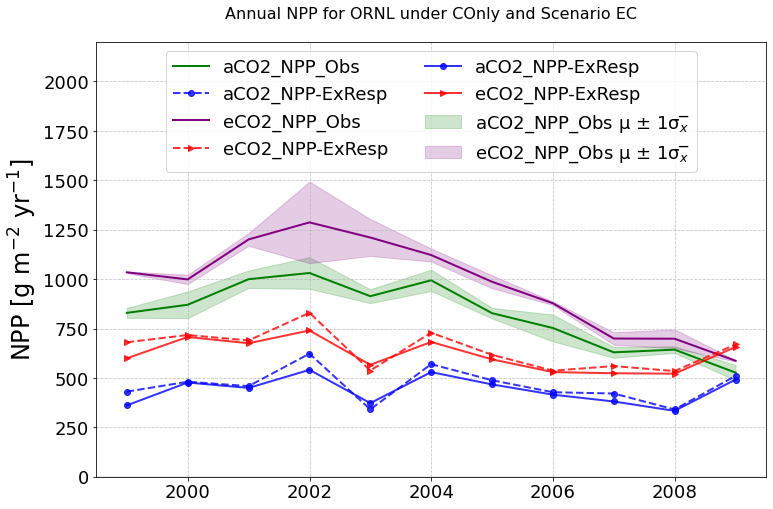

fig start RD
fig end RD ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_ORNL_RD.pdf


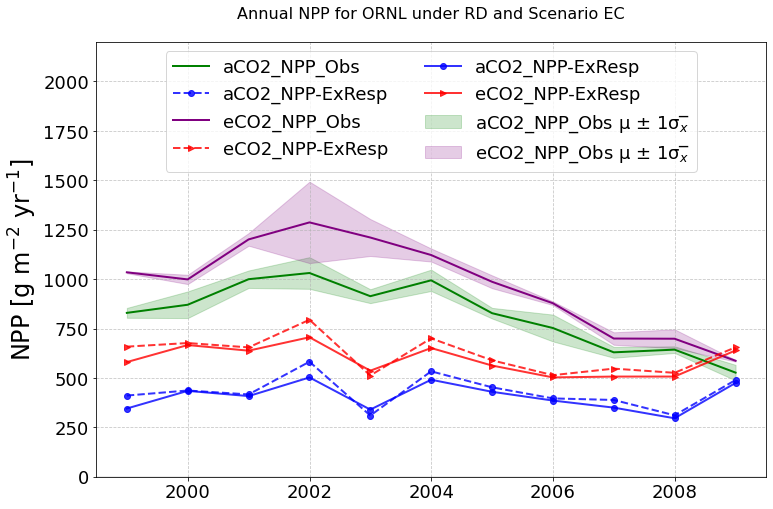

fig start ECA
fig end ECA ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_ORNL_ECA.pdf


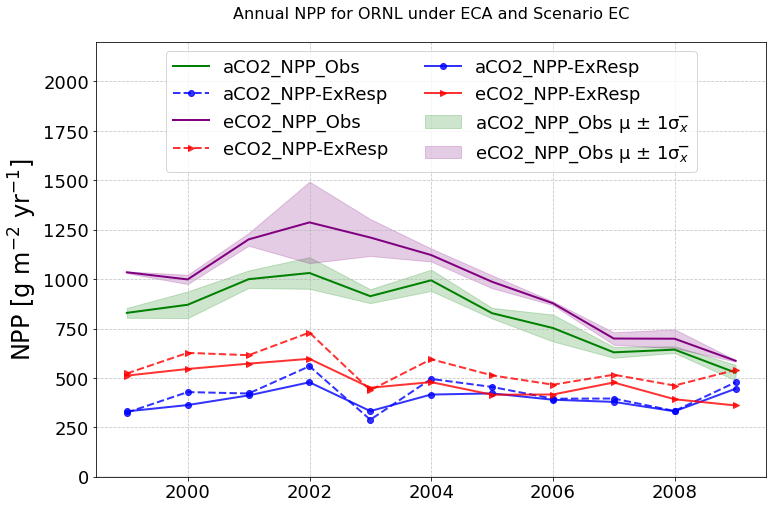

In [23]:

select_site = "US-ORN"
site = "ORNL"

data_plots[case_plot][site] = {}
data_plots_obs[site] = {}

li = 0 # for legend index
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in var_names:
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    color_line = "b"
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = "green"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if "eCO2" in key:
                    color_line = "r"
                    marker_line = ">"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = "purple"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if (obs_plot ==1) and (ran_twice<2):
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    years = Mean_DF['YEAR']
                    mean_npp = Mean_DF[f'{var_obs}']
                    se_npp = Standard_error_DF[f'{var_obs}']
                    # Plot NPP with shaded error bars
                    plt.plot(time, mean_npp, label=f'{tmp_case}_{var_obs}_Obs', color=color_obs, lw=2)
                    plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'{tmp_case}_{var_obs}_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                    #plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                    ran_twice +=1
                    
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+ "NPP-ExResp", 
                             label = tmp_case + '_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)

                if False:
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                
                plt.ylabel(r"NPP [g m$^{-2}$ yr$^{-1}$]", fontsize=fsize_labels)                
                plt.legend(fontsize=fsize_legend,loc="upper center", ncol=2)
                plt.xticks(fontsize=fsize_ticks)  # Increase x-axis tick font size
                plt.yticks(fontsize=fsize_ticks)  # Increase y-axis tick font size
                plt.ylim(ylim_variable)
                plt.title(f"Annual NPP for {site} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf")
    plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
    plt.show()
    plt.close()

fig start COnly
fig end COnly DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_DUKE_COnly.pdf
fig start RD
fig end RD DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_DUKE_RD.pdf
fig start ECA
fig end ECA DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_DUKE_ECA.pdf


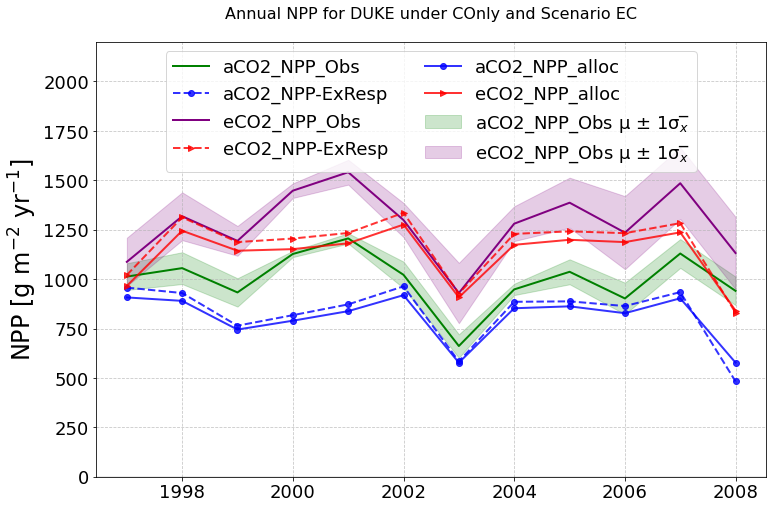

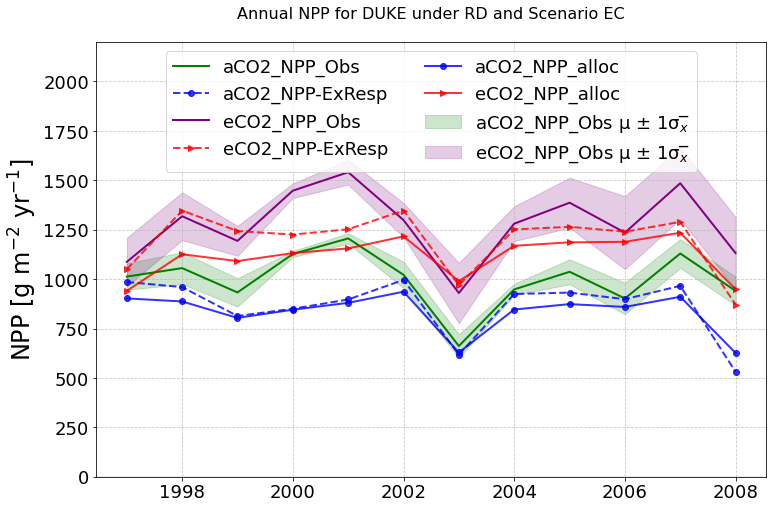

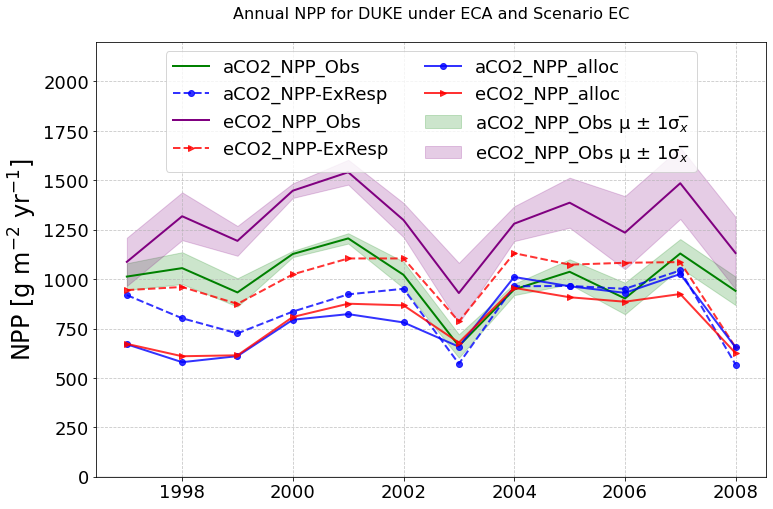

In [24]:
var_names = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_NPP-FATES_EXCESS_RESP",
        "NPP_alloc",
       )
select_site = "US-DUK"
site = "DUKE"

data_plots[case_plot][site] = {}
data_plots_obs[site] = {}

li = 0 # for legend index
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in var_names:
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range("1996-01-01", "2007-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    color_line = "b"
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = "green"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if "eCO2" in key:
                    color_line = "r"
                    marker_line = ">"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = "purple"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if (obs_plot ==1) and (ran_twice<2):
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    years = Mean_DF['YEAR']
                    mean_npp = Mean_DF['NPP']
                    se_npp = Standard_error_DF['NPP']
                    # Plot NPP with shaded error bars
                    plt.plot(time, mean_npp, label=f'{tmp_case}_NPP_Obs', color=color_obs, lw=2)
                    plt.fill_between(time, mean_npp - se_npp, mean_npp + se_npp, label=f'{tmp_case}_NPP_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                    #plt.fill_between(time, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color=color_obs, alpha=0.15)
                    ran_twice +=1
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                    
                if var =="FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var = (ds[key][var.split('-')[0]] - ds[key][var.split('-')[1]])*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_case+'_'+ "NPP-ExResp", 
                             color = color_line,
                             marker = marker_line,
                             linestyle = "--",
                             alpha=.8, linewidth=2) 
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var = ( 
                        ds[key]['FATES_CROOT_ALLOC'] +
                        ds[key]['FATES_FROOT_ALLOC'] +
                        ds[key]['FATES_LEAF_ALLOC'] +
                        ds[key]['FATES_SEED_ALLOC'] +
                        ds[key]['FATES_STEM_ALLOC'] 
                    )*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             label = tmp_case +'_'+var, 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                    #plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)

                if False:
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                
                plt.ylabel(r"NPP [g m$^{-2}$ yr$^{-1}$]", fontsize=fsize_labels)                
                plt.legend(fontsize=fsize_legend,loc="upper center", ncol=2)
                plt.xticks(fontsize=fsize_ticks)  # Increase x-axis tick font size
                plt.yticks(fontsize=fsize_ticks)  # Increase y-axis tick font size
                plt.ylim(ylim_variable)
                plt.title(f"Annual NPP for {site} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf")
    plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
        
    

/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_ORNL_COnly_Response.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_ORNL_RD_Response.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_ORNL_ECA_Response.pdf


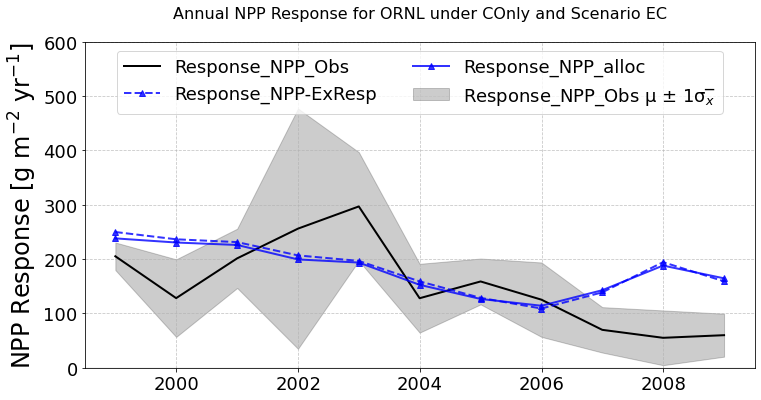

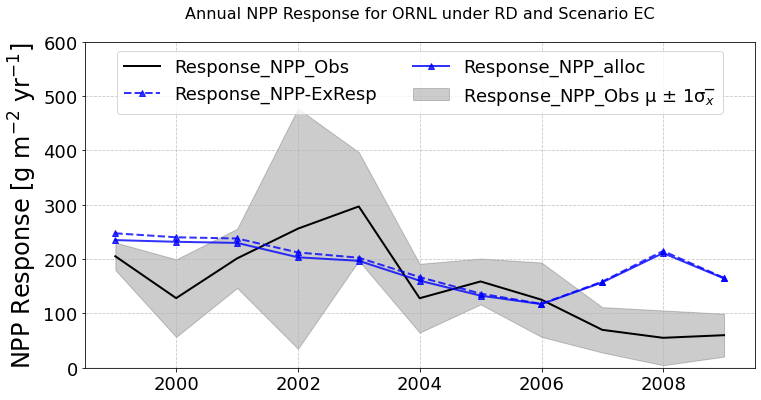

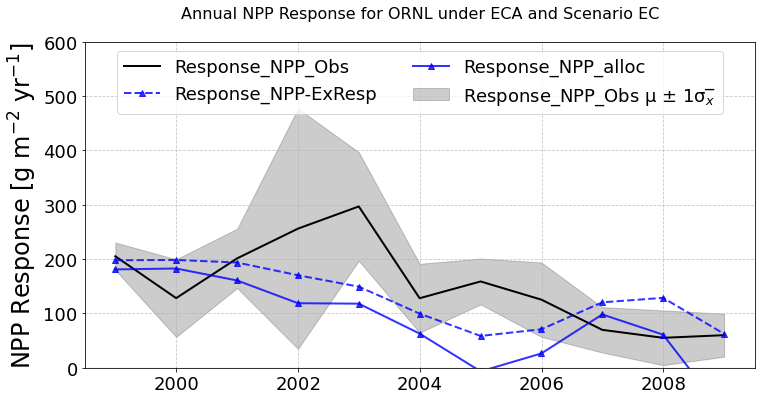

In [25]:
# NPP Response for ORNL
select_site = "US-ORN"
site = "ORNL"
li = 0  # for legend index
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12, 6))
    for var in var_names:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range(
                    "1998-01-01", "2008-12-31", freq="A"
                )  # Monthly data
                color_obs = "k"

                if (obs_plot == 1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = (
                        Mean_DF1[["YEAR", "NPP", "NUP"]]
                        - Mean_DF0[["YEAR", "NPP", "NUP"]]
                    )
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                        drop=True
                    )
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                        drop=True
                    )

                    Standard_error_DF = (
                        (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                        + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                    ) ** 0.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                    tmp_case = "Response"

                    # Extracting the relevant columns
                    years = Mean_DF["YEAR"]
                    mean_npp = Mean_DF["NPP"]
                    se_npp = Standard_error_DF["NPP"]
                    # Plot NPP with shaded error bars
                    plt.plot(
                        time,
                        mean_npp,
                        label=f"Response_NPP_Obs",
                        color=color_obs,
                        lw=2,
                    )
                    plt.fill_between(
                        time,
                        mean_npp - se_npp,
                        mean_npp + se_npp,
                        label=f"Response_NPP_Obs μ ± 1σ$_x̅$",
                        color=color_obs,
                        alpha=0.2,
                    )
                    data_plots_obs[site][var_obs][tmp_case] = {}
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                    #plt.fill_between(
                    #    time,
                    #    mean_npp - se_npp * 1.96,
                    #    mean_npp + se_npp * 1.96,
                    #    color=color_obs,
                    #    alpha=0.15,
                    #)

                    ran_once = True

                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var == "FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (
                        (ds[key][var.split("-")[0]] - ds[key][var.split("-")[1]])
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2][var.split("-")[0]]
                            - ds[key_eCO2][var.split("-")[1]]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )

                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + "NPP-ExResp",
                        color=color_line,
                        marker=marker_line,
                        linestyle="--",
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = (
                        (
                            ds[key]["FATES_CROOT_ALLOC"]
                            + ds[key]["FATES_FROOT_ALLOC"]
                            + ds[key]["FATES_LEAF_ALLOC"]
                            + ds[key]["FATES_SEED_ALLOC"]
                            + ds[key]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2]["FATES_CROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                            + ds[key_eCO2]["FATES_SEED_ALLOC"]
                            + ds[key_eCO2]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + var,
                        color=color_line,
                        marker=marker_line,
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)
                if False:
                    print(ds[key][var].long_name)
                plt.axhline(y=0, color="k", lw=2, alpha=0.02)
                plt.grid(
                    True, linestyle="--", alpha=0.7
                )  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"NPP Response [g m$^{-2}$ yr$^{-1}$]", fontsize=fsize_labels)             
                plt.legend(fontsize=fsize_legend,loc="upper center", ncol=2)
                plt.xticks(fontsize=fsize_ticks)  # Increase x-axis tick font size
                plt.yticks(fontsize=fsize_ticks)  # Increase y-axis tick font size
                plt.ylim(ylim_response)
                plt.title(
                    f"Annual NPP Response for {site} under {sim_case} and Scenario {case_plot}\n",
                    fontsize=16,
                )
                # li+=1 # for legend index updating for a sit

    print(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf"
    )
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )
    

/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_DUKE_COnly_Response.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_DUKE_RD_Response.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/NPP_sce_EC_DUKE_ECA_Response.pdf


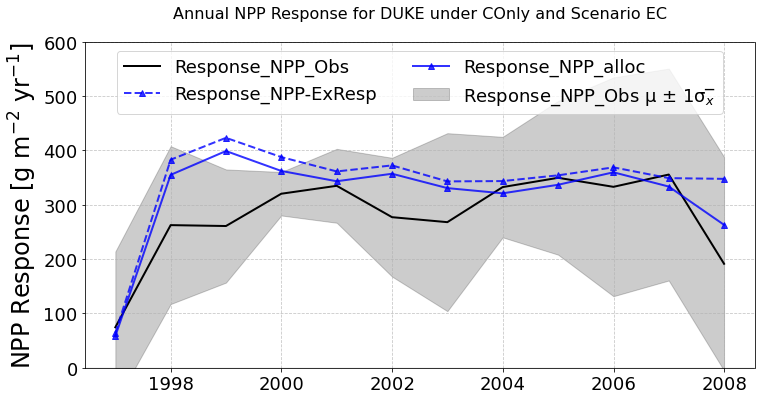

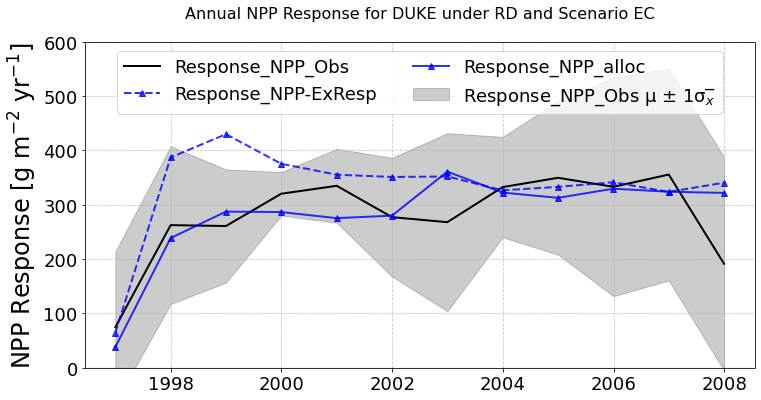

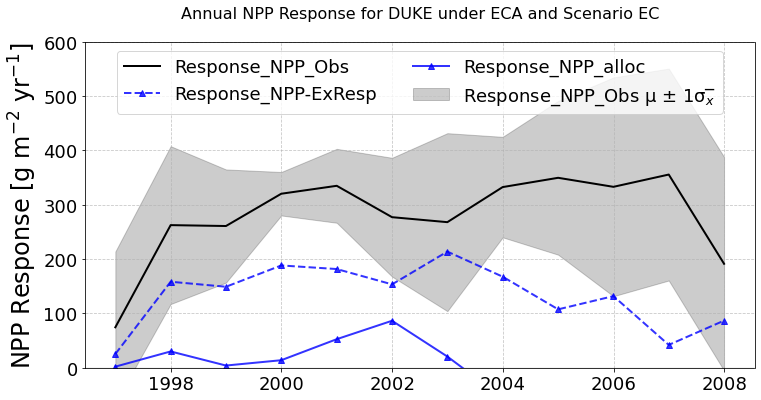

In [26]:
# NPP Response for ORNL
select_site = "US-DUK"
site = "DUKE"
li = 0  # for legend index
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12, 6))
    for var in var_names:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range(
                    "1996-01-01", "2007-12-31", freq="A"
                )  # Yearly data
                color_obs = "k"

                if (obs_plot == 1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = (
                        Mean_DF1[["YEAR", "NPP", "NUP"]]
                        - Mean_DF0[["YEAR", "NPP", "NUP"]]
                    )
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                        drop=True
                    )
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                        drop=True
                    )

                    Standard_error_DF = (
                        (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                        + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                    ) ** 0.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                    tmp_case = "Response"

                    # Extracting the relevant columns
                    years = Mean_DF["YEAR"]
                    mean_npp = Mean_DF["NPP"]
                    se_npp = Standard_error_DF["NPP"]
                    # Plot NPP with shaded error bars
                    plt.plot(
                        time,
                        mean_npp,
                        label=f"Response_NPP_Obs",
                        color=color_obs,
                        lw=2,
                    )
                    plt.fill_between(
                        time,
                        mean_npp - se_npp,
                        mean_npp + se_npp,
                        label=f"Response_NPP_Obs μ ± 1σ$_x̅$",
                        color=color_obs,
                        alpha=0.2,
                    )
                    data_plots_obs[site][var_obs][tmp_case] = {}
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                    data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                    #plt.fill_between(
                    #    time,
                    #    mean_npp - se_npp * 1.96,
                    #    mean_npp + se_npp * 1.96,
                    #    color=color_obs,
                    #    alpha=0.15,
                    #)

                    ran_once = True

                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var == "FATES_NPP-FATES_EXCESS_RESP":
                    tmp_var_a = (
                        (ds[key][var.split("-")[0]] - ds[key][var.split("-")[1]])
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2][var.split("-")[0]]
                            - ds[key_eCO2][var.split("-")[1]]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )

                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label= tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + "NPP-ExResp",
                        color=color_line,
                        marker=marker_line,
                        linestyle="--",
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: {ds[key][var.split('-')[0]].units}\n",fontsize=14)
                if var == "NPP_alloc":
                    tmp_var_a = (
                        (
                            ds[key]["FATES_CROOT_ALLOC"]
                            + ds[key]["FATES_FROOT_ALLOC"]
                            + ds[key]["FATES_LEAF_ALLOC"]
                            + ds[key]["FATES_SEED_ALLOC"]
                            + ds[key]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = (
                        (
                            ds[key_eCO2]["FATES_CROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                            + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                            + ds[key_eCO2]["FATES_SEED_ALLOC"]
                            + ds[key_eCO2]["FATES_STEM_ALLOC"]
                        )
                        * 24
                        * 3600
                        * 365
                        * 1000
                    )
                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + var,
                        color=color_line,
                        marker=marker_line,
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: g m-2 yr-1\n",fontsize=14)
                if False:
                    print(ds[key][var].long_name)
                plt.axhline(y=0, color="k", lw=2, alpha=0.02)
                plt.grid(
                    True, linestyle="--", alpha=0.7
                )  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"NPP Response [g m$^{-2}$ yr$^{-1}$]", fontsize=fsize_labels)             
                plt.legend(fontsize=fsize_legend,loc="upper center", ncol=2)
                plt.xticks(fontsize=fsize_ticks)  # Increase x-axis tick font size
                plt.yticks(fontsize=fsize_ticks)  # Increase y-axis tick font size
                plt.ylim(ylim_response)
                plt.title(
                    f"Annual NPP Response for {site} under {sim_case} and Scenario {case_plot}\n",
                    fontsize=16,
                )
                # li+=1 # for legend index updating for a site

    print(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf"
    )
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )
    